# CRIMENET — Complete Network Science Analysis

## Analysis of the global criminal alliance and rivalry network.

# Setup & data loading

In [1]:
import os
import json
import warnings
import powerlaw

import numpy             as np
import pandas            as pd
import seaborn           as sns
import matplotlib.cm     as cm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from math                    import log2
from openai                  import OpenAI
from infomap                 import Infomap
from adjustText              import adjust_text
from scipy.stats             import norm
from collections             import Counter, defaultdict
from numpy.random            import default_rng
from graph_tool.all          import (Graph, GraphView, graph_draw, sfdp_layout, random_rewire)
from matplotlib.lines        import Line2D
from matplotlib.ticker       import MaxNLocator
from matplotlib.patches      import Patch
from graph_tool.topology     import (kcore_decomposition, label_largest_component,label_components, pseudo_diameter, shortest_distance)
from graph_tool.centrality   import betweenness, pagerank
from graph_tool.clustering   import global_clustering, local_clustering
from graph_tool.correlations import scalar_assortativity

In [2]:
warnings.filterwarnings("ignore")

In [3]:
# Output directory
os.makedirs("images", exist_ok=True)

# --- Global plot style ---
# All figures: no top/right spines, no grid, white background, saved as PDF.

def style_ax(ax):
    """Remove top/right spines and grid for clean figures."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

def style_axes(axes):
    """Apply style_ax to one or many axes."""
    for ax in np.array(axes).flat:
        style_ax(ax)

def savefig(name):
    """Save current figure to images/ as PDF."""
    plt.savefig(f"images/{name}.pdf", dpi=200, bbox_inches="tight")

# %%
# --- Load data ---
INPUT_FILE = "../crimenet.json"
with open(INPUT_FILE, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

entities = raw_data["entities"]
relations = raw_data["relations"]
entity_map = {ent["name"]: ent for ent in entities}
entity_type_map = {ent["name"]: ent.get("type", "unknown") for ent in entities}

print(f"Loaded: {len(entities)} entities, {len(relations)} relations")

Loaded: 2426 entities, 3354 relations


In [4]:
# --- Build the full graph (all edge types) ---
g = Graph(directed=False)

# Vertex properties
vp_name               = g.new_vertex_property("string")
vp_type               = g.new_vertex_property("string")
vp_has_own_source     = g.new_vertex_property("bool")
vp_mentioned_in_count = g.new_vertex_property("int32_t")
vp_descriptions       = g.new_vertex_property("object")
vp_time_period        = g.new_vertex_property("string")
vp_own_source_url     = g.new_vertex_property("string")
vp_mentioned_in       = g.new_vertex_property("object")
vp_betw_alliance      = g.new_vertex_property("double")
vp_betw_rivalry       = g.new_vertex_property("double")
vp_betw_combined      = g.new_vertex_property("double") 

# Edge properties
ep_type         = g.new_edge_property("string")
ep_descriptions = g.new_edge_property("object")
ep_n_sources    = g.new_edge_property("int32_t")
ep_is_infobox   = g.new_edge_property("bool")
ep_time_period  = g.new_edge_property("string")

name_to_vertex = {}

def get_or_create(name):
    """Get existing vertex or create a new one with all properties."""
    if name in name_to_vertex:
        return name_to_vertex[name]
    v                        = g.add_vertex()
    vp_name[v]               = name
    ent                      = entity_map.get(name, {})
    vp_type[v]               = ent.get("type", "unknown")
    vp_has_own_source[v]     = bool(ent.get("own_source"))
    vp_mentioned_in_count[v] = len(ent.get("mentioned_in", []))
    vp_descriptions[v]       = ent.get("descriptions", [])
    vp_time_period[v]        = ent.get("time_period") or ""
    own                      = ent.get("own_source")
    vp_own_source_url[v]     = own.get("url", "") if own else ""
    vp_mentioned_in[v]       = ent.get("mentioned_in", [])
    vp_betw_alliance[v]      = ent.get("betweenness_alliance", 0.0)
    vp_betw_rivalry[v]       = ent.get("betweenness_rivalry", 0.0)
    vp_betw_combined[v]      = ent.get("betweenness_combined", 0.0)
    name_to_vertex[name]     = v
    return v

# Add all entities as vertices
for ent in entities:
    get_or_create(ent["name"])

# Add all relations as edges
for rel in relations:
    src = get_or_create(rel["source"])
    tgt = get_or_create(rel["target"])
    
    if src != tgt:
        e                  = g.add_edge(src, tgt)
        ep_type[e]         = rel.get("type", "unknown")
        descs              = rel.get("descriptions", [])
        ep_descriptions[e] = descs
        ep_n_sources[e]    = len(rel.get("sources", []))
        ep_is_infobox[e]   = all("infobox" in d.lower() for d in descs)
        ep_time_period[e]  = rel.get("time_period") or ""

print(f"Graph: {g.num_vertices()} vertices, {g.num_edges()} edges")

Graph: 2426 vertices, 3354 edges


In [22]:
# 1. Count nodes that have at least one connection
connected_nodes = sum(1 for v in g.vertices() if v.out_degree() > 0)

# 2. The edge count remains identical because isolated nodes have no edges to remove.
total_edges = g.num_edges()

print(f"Filtered Graph: {connected_nodes} vertices, {total_edges} edges")

Filtered Graph: 1890 vertices, 3354 edges


In [5]:
# --- Build alliance and rivalry layers ---

def get_layer(edge_label, filter_isolated=True):
    """Return a GraphView filtered to one edge type, optionally removing isolates."""
    mask_e = g.new_edge_property("bool")
    for e in g.edges():
        mask_e[e] = (ep_type[e] == edge_label)
    g_layer = GraphView(g, efilt=mask_e)
    
    if filter_isolated:
        mask_v = g.new_vertex_property("bool")
        for v in g_layer.vertices():
            mask_v[v] = (v.out_degree() > 0)
        return GraphView(g_layer, vfilt=mask_v)
    
    return g_layer

g_ally  = get_layer("allied_with")
g_rival = get_layer("rivals_with")

print(f"Alliance layer: {g_ally.num_vertices()}  vertices, {g_ally.num_edges()}  edges")
print(f"Rivalry layer:  {g_rival.num_vertices()} vertices, {g_rival.num_edges()} edges")

# --- Compute centralities once (reused throughout) ---
bw_ally, _  = betweenness(g_ally)
pr_ally     = pagerank(g_ally)
bw_rival, _ = betweenness(g_rival)
pr_rival    = pagerank(g_rival)

# --- Master dataframe with all node info ---
df_full = pd.DataFrame([{
    "name":            vp_name[v],
    "type":            vp_type[v],
    "description":     vp_descriptions[v][0] if vp_descriptions[v] else "",
    "has_own_source":  int(vp_has_own_source[v]),
    "mentioned_in":    vp_mentioned_in_count[v],
    "time_period":     vp_time_period[v],
    "betw_alliance":   vp_betw_alliance[v],
    "betw_rivalry":    vp_betw_rivalry[v],
    "betw_combined":   vp_betw_combined[v],
    "degree_alliance": g_ally.vertex(v).out_degree() if v in g_ally.get_vertices() else 0,
    "degree_rivalry":  g_rival.vertex(v).out_degree() if v in g_rival.get_vertices() else 0,
    "degree_total":    v.out_degree(),
    "pr_alliance":     pr_ally[v] if int(v) in g_ally.get_vertices() else 0,
    "pr_rivalry":      pr_rival[v] if int(v) in g_rival.get_vertices() else 0,
} for v in g.vertices()])

# --- Type colors and ordering ---

DANGER_ORDER = [
    "faction", "gang", "motorcycle_club", "clan", "triad",
    "mafia", "cartel", "militia", "terrorist_organization",
]

cmap = cm.get_cmap("Spectral_r")
TYPE_COLORS = {
    t: mcolors.to_hex(cmap(i / (len(DANGER_ORDER) - 1)))
    for i, t in enumerate(DANGER_ORDER)
}

def type_legend(ax, types, ncols=3, loc="upper left", **kwargs):
    """Add a legend with type-colored markers, sorted by DANGER_ORDER."""
    valid = [t for t in DANGER_ORDER if t in types]
    elements = [
        Line2D([0], [0], marker="o", color="none",
               markerfacecolor=TYPE_COLORS.get(t, "#999"),
               markeredgecolor="white", markeredgewidth=0.3, markersize=20,
               label=t.replace("_", " ").title())
        for t in valid
    ]
    ax.legend(handles=elements, loc=loc, frameon=True, ncols=ncols, **kwargs)

Alliance layer: 1517  vertices, 2293  edges
Rivalry layer:  876 vertices, 1061 edges


# Data census

In [6]:
# Type distribution
type_counts = Counter(vp_type[v] for v in g.vertices())
print(f"Organization types ({len(type_counts)} unique):")
for t, c in sorted(type_counts.items(), key=lambda x: -x[1]):
    print(f"  {t:35s} {c:5d}  ({100*c/g.num_vertices():.1f}%)")

# Coverage stats
has_time = sum(1 for v in g.vertices() if vp_time_period[v] != "")
has_own  = sum(1 for v in g.vertices() if vp_has_own_source[v])
mi_counts = [vp_mentioned_in_count[v] for v in g.vertices()]

print(f"\nTime period coverage: {has_time}/{g.num_vertices()} ({100*has_time/g.num_vertices():.1f}%)")
print(f"Own Wikipedia page:  {has_own}/{g.num_vertices()} ({100*has_own/g.num_vertices():.1f}%)")
print(f"Mentioned-in: min={min(mi_counts)}, max={max(mi_counts)}, mean={np.mean(mi_counts):.2f}")

# Edge types
edge_type_counts = Counter(ep_type[e] for e in g.edges())
print(f"\nEdge types:")
for t, c in sorted(edge_type_counts.items(), key=lambda x: -x[1]):
    print(f"  {t:25s} {c:5d}  ({100*c/g.num_edges():.1f}%)")

infobox_edges = sum(1 for e in g.edges() if ep_is_infobox[e])
multi_source  = sum(1 for e in g.edges() if ep_n_sources[e] >= 2)
print(f"\nInfobox-only edges: {infobox_edges} ({100*infobox_edges/g.num_edges():.1f}%)")
print(f"Multi-source edges: {multi_source} ({100*multi_source/g.num_edges():.1f}%)")

# Top cross-referenced orgs
print(f"\nTop 10 most cross-referenced:")
top_mi = sorted(g.vertices(), key=lambda v: -vp_mentioned_in_count[v])[:10]
for v in top_mi:
    print(f"  {vp_name[v]:40s} mentioned in {vp_mentioned_in_count[v]} articles")

Organization types (9 unique):
  gang                                  964  (39.7%)
  clan                                  328  (13.5%)
  mafia                                 325  (13.4%)
  motorcycle_club                       253  (10.4%)
  faction                               226  (9.3%)
  cartel                                105  (4.3%)
  militia                               103  (4.2%)
  triad                                  69  (2.8%)
  terrorist_organization                 53  (2.2%)

Time period coverage: 1612/2426 (66.4%)
Own Wikipedia page:  456/2426 (18.8%)
Mentioned-in: min=0, max=93, mean=2.32

Edge types:
  allied_with                2293  (68.4%)
  rivals_with                1061  (31.6%)

Infobox-only edges: 317 (9.5%)
Multi-source edges: 763 (22.7%)

Top 10 most cross-referenced:
  Hells Angels                             mentioned in 93 articles
  Sinaloa Cartel                           mentioned in 69 articles
  'Ndrangheta                              mentio

In [7]:
def compute_layer_metrics(g_layer, edge_label):
    """Compute a full set of network metrics for one layer."""
    g_unfiltered = get_layer(edge_label, filter_isolated=False)
    N_total = g_unfiltered.num_vertices()
    n_isolated = sum(1 for v in g_unfiltered.vertices() if v.out_degree() == 0)

    N = g_layer.num_vertices()
    E = g_layer.num_edges()
    degrees = np.array([v.out_degree() for v in g_layer.vertices()])

    comp, hist = label_components(g_layer)
    lcc_mask = label_largest_component(g_layer)
    g_lcc = GraphView(g_layer, vfilt=lcc_mask)
    diam, _ = pseudo_diameter(g_lcc)
    gc = global_clustering(g_layer)[0]
    lc = local_clustering(g_layer)
    lc_vals = [lc[v] for v in g_layer.vertices() if v.out_degree() >= 2]
    r_deg, _ = scalar_assortativity(g_layer, "total")
    kc = kcore_decomposition(g_layer)
    bw, _ = betweenness(g_layer)
    pr = pagerank(g_layer)
    return {
#         "Total nodes": N_total,
        "Active nodes (deg>0)": f"{N}",
#         "Isolated (deg=0)": f"{n_isolated}",
        "Edges": E,
        "Density": f"{2*E/(N*(N-1)):.5f}" if N > 1 else "0",
        "Mean degree": f"{degrees.mean():.2f}",
        "Median degree": f"{np.median(degrees):.0f}",
        "Max degree": f"{degrees.max()}",
        "Components": f"{len(hist)}",
        "LCC nodes": f"{g_lcc.num_vertices()} ({100*g_lcc.num_vertices()/N:.1f}%)",
        "LCC edges": f"{g_lcc.num_edges()} ({100*g_lcc.num_edges()/E:.1f}%)",
        "LCC density": f"{2*g_lcc.num_edges()/(g_lcc.num_vertices()*(g_lcc.num_vertices()-1)):.5f}" if g_lcc.num_vertices() > 1 else "0",
        "Pseudo-diameter (LCC)": f"{int(diam)}",
        "Global clustering": f"{gc:.4f}",
        "Mean local clustering": f"{np.mean(lc_vals):.4f}" if lc_vals else "—",
        "Degree assortativity": f"{r_deg:.4f}",
        "Max k-core": f"{max(kc[v] for v in g_layer.vertices())}",
        "Max betweenness": f"{max(bw[v] for v in g_layer.vertices()):.6f}",
        "Max PageRank": f"{max(pr[v] for v in g_layer.vertices()):.6f}",
    }

print("\nComputing layer metrics...")
m_a = compute_layer_metrics(g_ally, "allied_with")
m_r = compute_layer_metrics(g_rival, "rivals_with")

print(f"\n{'Metric':35s} {'Alliance':>20s} {'Rivalry':>20s}")
print("-" * 78)
for key in m_a:
    print(f"{key:35s} {str(m_a[key]):>20s} {str(m_r[key]):>20s}")


Computing layer metrics...

Metric                                          Alliance              Rivalry
------------------------------------------------------------------------------
Active nodes (deg>0)                                1517                  876
Edges                                               2293                 1061
Density                                          0.00199              0.00277
Mean degree                                         3.02                 2.42
Median degree                                          1                    1
Max degree                                           134                   53
Components                                            68                  102
LCC nodes                                   1292 (85.2%)          478 (54.6%)
LCC edges                                   2130 (92.9%)          744 (70.1%)
LCC density                                      0.00255              0.00653
Pseudo-diameter (LCC)             

In [8]:
def categorical_assortativity(g, vp_type):
    """
    Calculates Newman's assortativity coefficient for a categorical vertex property.
    """
    # 1. Map unique types to integer indices
    types = list(set(vp_type[v] for v in g.vertices()))
    type_to_int = {t: i for i, t in enumerate(types)}
    k = len(types)

    # 2. Build the mixing matrix
    e = np.zeros((k, k))
    for edge in g.edges():
        s_type = type_to_int[vp_type[edge.source()]]
        t_type = type_to_int[vp_type[edge.target()]]
        
        e[s_type, t_type] += 1
        # If the graph is undirected, edges are yielded once, so we must make it symmetric
        if not g.is_directed():
            e[t_type, s_type] += 1

    # 3. Normalize the matrix to get probabilities
    if e.sum() == 0:
        return 0.0 # Handle empty graph edge case
    e = e / e.sum()

    # 4. Calculate Newman's categorical r
    trace_e = np.trace(e)          # Sum of diagonal (observed assortativity)
    a = e.sum(axis=1)              # Row sums
    b = e.sum(axis=0)              # Column sums
    expected = np.sum(a * b)       # Expected assortativity by chance

    # Handle edge case where expected is 1 (prevents division by zero)
    if expected == 1.0:
        return 1.0

    r = (trace_e - expected) / (1 - expected)
    return r

# --- Applying it to your layers ---

r_type_ally = categorical_assortativity(g_ally, vp_type)
r_type_rival = categorical_assortativity(g_rival, vp_type)

print(f"\nType assortativity (Newman's categorical r):")
print(f"  Alliance: r = {r_type_ally:.4f}")
print(f"  Rivalry:  r = {r_type_rival:.4f}")
print(f"  → {'Rivalries' if r_type_rival > r_type_ally else 'Alliances'} are more type-assortative")


Type assortativity (Newman's categorical r):
  Alliance: r = 0.4859
  Rivalry:  r = 0.6416
  → Rivalries are more type-assortative


In [9]:
def bootstrap_categorical_assortativity(g, vp_type, num_bootstraps=1000):
    """
    Calculates the standard error of Newman's r using edge bootstrapping.
    """
    types = list(set(vp_type[v] for v in g.vertices()))
    type_to_int = {t: i for i, t in enumerate(types)}
    k = len(types)
    
    # Extract edges as integer tuples for fast resampling
    edges = [(type_to_int[vp_type[e.source()]], type_to_int[vp_type[e.target()]]) for e in g.edges()]
    n_edges = len(edges)
    
    if n_edges == 0:
        return 0.0, 0.0
        
    edges_array = np.array(edges)
    r_bootstraps = []
    
    for _ in range(num_bootstraps):
        # Resample edges with replacement
        indices = np.random.choice(n_edges, size=n_edges, replace=True)
        resampled_edges = edges_array[indices]
        
        # Build mixing matrix for this bootstrap sample
        e = np.zeros((k, k))
        for s_type, t_type in resampled_edges:
            e[s_type, t_type] += 1
            if not g.is_directed():
                e[t_type, s_type] += 1
                
        e = e / e.sum()
        trace_e = np.trace(e)
        a = e.sum(axis=1)
        b = e.sum(axis=0)
        expected = np.sum(a * b)
        
        if expected != 1.0:
            r = (trace_e - expected) / (1 - expected)
            r_bootstraps.append(r)
            
    # Return the empirical mean and standard error (standard deviation of the bootstraps)
    return np.mean(r_bootstraps), np.std(r_bootstraps)

# --- Run the statistical test ---

print("Bootstrapping Alliance Layer (1000 iterations)...")
r_ally_mean, r_ally_se = bootstrap_categorical_assortativity(g_ally, vp_type)

print("Bootstrapping Rivalry Layer (1000 iterations)...")
r_rival_mean, r_rival_se = bootstrap_categorical_assortativity(g_rival, vp_type)

# Calculate 95% Confidence Intervals (± 1.96 * standard error)
ci_ally = (r_ally_mean - 1.96 * r_ally_se, r_ally_mean + 1.96 * r_ally_se)
ci_rival = (r_rival_mean - 1.96 * r_rival_se, r_rival_mean + 1.96 * r_rival_se)

# Perform a two-sample Z-test
# Formula: Z = (r1 - r2) / sqrt(SE1^2 + SE2^2)
z_score = (r_rival_mean - r_ally_mean) / np.sqrt(r_ally_se**2 + r_rival_se**2)
p_value = 2 * (1 - norm.cdf(abs(z_score))) # Two-tailed p-value

print("\n--- STATISTICAL RESULTS ---")
print(f"Alliance r: {r_ally_mean:.4f}  (95% CI: [{ci_ally[0]:.4f}, {ci_ally[1]:.4f}], SE: {r_ally_se:.4f})")
print(f"Rivalry r:  {r_rival_mean:.4f}  (95% CI: [{ci_rival[0]:.4f}, {ci_rival[1]:.4f}], SE: {r_rival_se:.4f})")

print(f"\nZ-score: {z_score:.4f}")
print(f"p-value: {p_value}")

if p_value < 0.05:
    print("\nCONCLUSION: Yes, this is statistically true. The difference in assortativity is significant (p < 0.05).")
else:
    print("\nCONCLUSION: No, this is NOT statistically true. The difference is not significant (p >= 0.05). The true assortativity of both layers could realistically be the same.")

Bootstrapping Alliance Layer (1000 iterations)...
Bootstrapping Rivalry Layer (1000 iterations)...

--- STATISTICAL RESULTS ---
Alliance r: 0.4857  (95% CI: [0.4605, 0.5109], SE: 0.0128)
Rivalry r:  0.6408  (95% CI: [0.6038, 0.6778], SE: 0.0189)

Z-score: 6.7910
p-value: 1.1135758981595245e-11

CONCLUSION: Yes, this is statistically true. The difference in assortativity is significant (p < 0.05).


# Top organizations by centrality

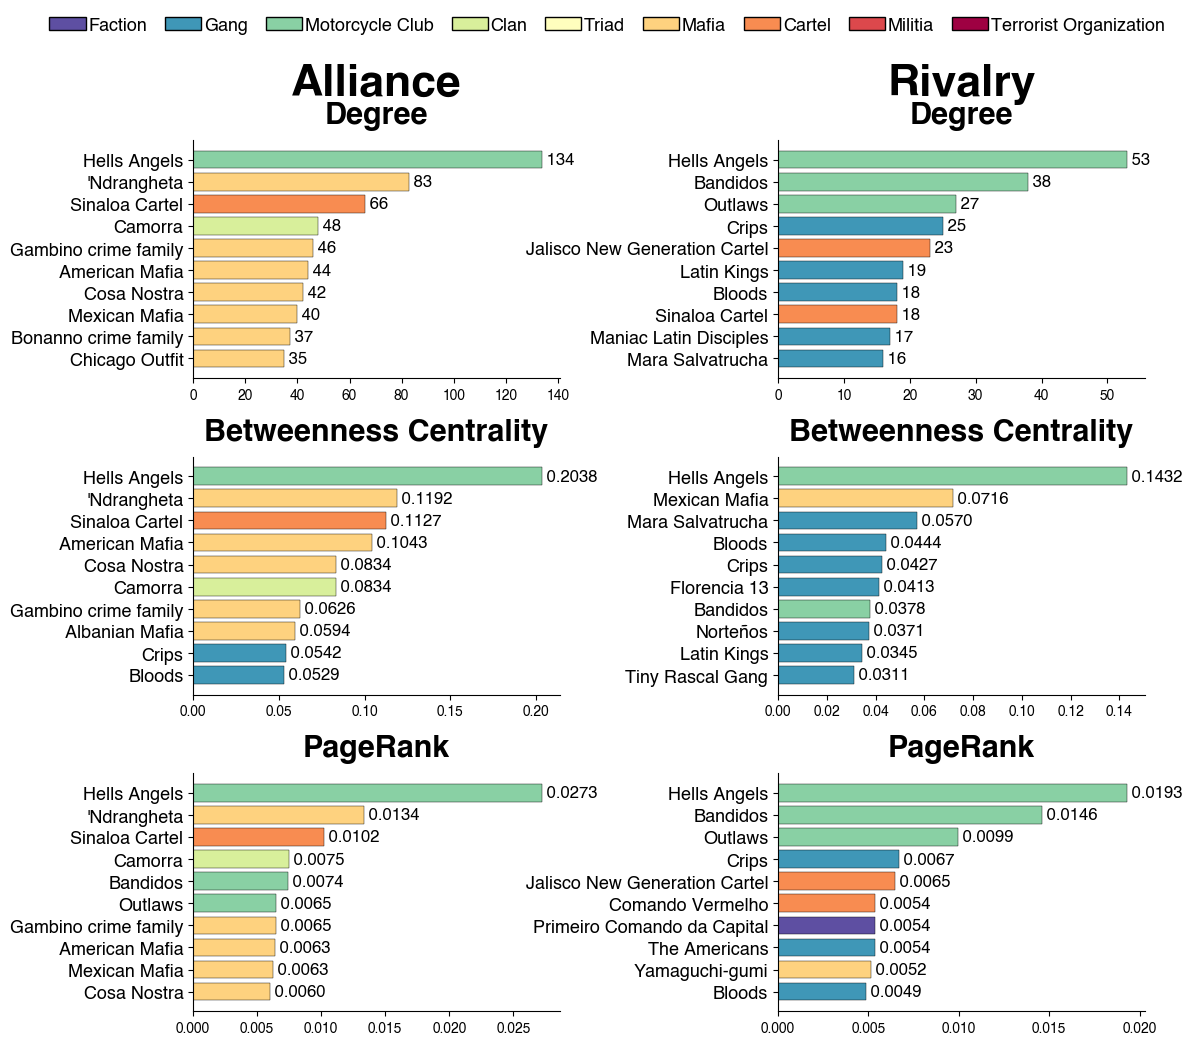

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
style_axes(axes)

configs = [
    ("Alliance", "degree_alliance", "betw_alliance", "pr_alliance"),
    ("Rivalry",  "degree_rivalry",  "betw_rivalry",  "pr_rivalry"),
]
titles = ["Degree", "Betweenness Centrality", "PageRank"]

for col, (layer, deg_col, bw_col, pr_col) in enumerate(configs):
    for row, (metric, title) in enumerate(zip([deg_col, bw_col, pr_col], titles)):
        ax = axes[row, col]
        top10 = df_full.nlargest(10, metric).iloc[::-1]
        colors = [TYPE_COLORS.get(t, "#999") for t in top10["type"]]
        ax.barh(range(10), top10[metric], color=colors, edgecolor="k", linewidth=0.3)
        ax.set_yticks(range(10))
        ax.set_yticklabels(top10["name"], fontsize=13)
        
        # Set the metric title
        ax.set_title(title, fontsize=22, fontweight="bold", pad=12)
        
        # Add the layer name (Alliance/Rivalry) above the top row, making it larger
        if row == 0:
            ax.text(0.5, 1.15, layer, transform=ax.transAxes, ha="center", va="bottom", fontsize=32, fontweight="bold")
        
        for i, (_, r) in enumerate(top10.iterrows()):
            val = r[metric]
            label = f"{val:.4f}" if "degree" not in metric else str(int(val))
            ax.text(val, i, f" {label}", va="center", fontsize=12)
            
# Single legend at the top
handles = [
    Patch(facecolor=TYPE_COLORS.get(t, "#999"), edgecolor="black", linewidth=1,
          label=t.replace("_", " ").title())
    for t in DANGER_ORDER
]

fig.legend(handles=handles, loc="upper center", ncols=len(DANGER_ORDER)//1,
           fontsize=13, frameon=False, bbox_to_anchor=(0.51, 1.05),
            columnspacing=1,     # <-- Decreases the space between different labels/columns (Default is ~2.0)
            handletextpad=.15      # <-- (Optional) Decreases the space between the color box and the text (Default is ~0.8)
          )

plt.tight_layout(w_pad=-5)
savefig("crimenet_top10_centrality")
plt.show()

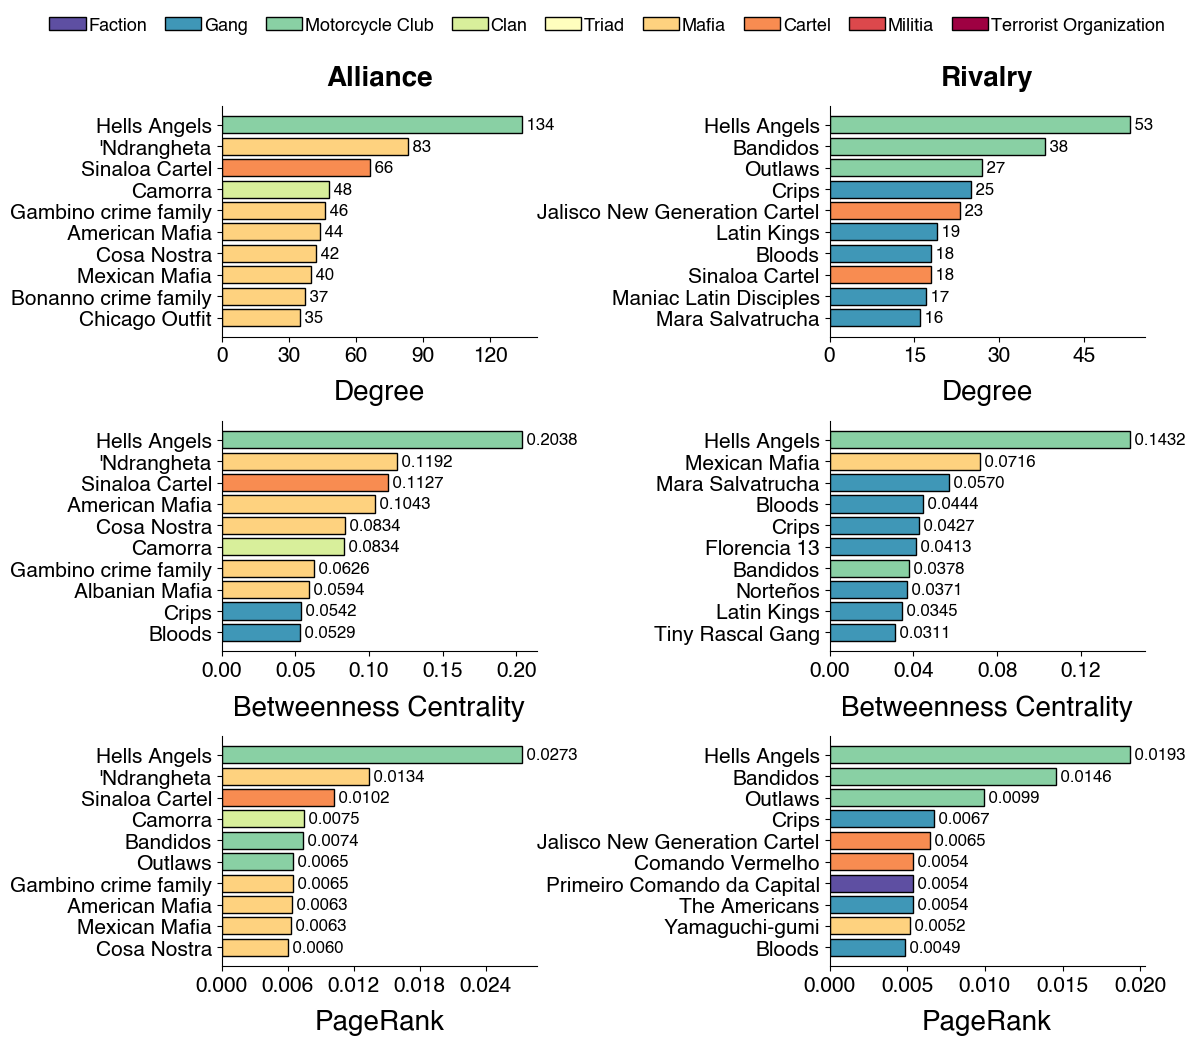

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
style_axes(axes)
configs = [
    ("Alliance", "degree_alliance", "betw_alliance", "pr_alliance"),
    ("Rivalry",  "degree_rivalry",  "betw_rivalry",  "pr_rivalry"),
]
titles = ["Degree", "Betweenness Centrality", "PageRank"]
xlabels = ["Degree", "Betweenness Centrality", "PageRank"]
for col, (layer, deg_col, bw_col, pr_col) in enumerate(configs):
    for row, (metric, title, xlabel) in enumerate(zip([deg_col, bw_col, pr_col], titles, xlabels)):
        ax = axes[row, col]
        top10 = df_full.nlargest(10, metric).iloc[::-1]
        colors = [TYPE_COLORS.get(t, "#999") for t in top10["type"]]
        ax.barh(range(10), top10[metric], color=colors, edgecolor="k")
        ax.set_yticks(range(10))
        ax.set_yticklabels(top10["name"], fontsize=20)
        ax.set_xlabel(xlabel, fontsize=20, labelpad=10)
        ax.tick_params(labelsize=15)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))

        # Title: layer name on top row only
        if row == 0:
            ax.set_title(layer, fontsize=20, fontweight="bold", pad=15)

        # Bar value labels
        for i, (_, r) in enumerate(top10.iterrows()):
            val = r[metric]
            label = f"{val:.4f}" if "degree" not in metric else str(int(val))
            ax.text(val, i, f" {label}", va="center", fontsize=12)
            
# Single legend at the top
handles = [
    Patch(facecolor=TYPE_COLORS.get(t, "#999"), edgecolor="black", linewidth=1,
          label=t.replace("_", " ").title())
    for t in DANGER_ORDER
]

fig.legend(handles=handles, loc="upper center", ncols=len(DANGER_ORDER)//1,
           fontsize=13, frameon=False, bbox_to_anchor=(0.51, 1.05),
            columnspacing=1,     # <-- Decreases the space between different labels/columns (Default is ~2.0)
            handletextpad=.15      # <-- (Optional) Decreases the space between the color box and the text (Default is ~0.8)
          )

plt.tight_layout(w_pad=-2.5)
savefig("crimenet_top10_centrality")
plt.show()

# K-Core shell decomposition

In [12]:
def kcore_analysis(g_layer, bw_layer, pr_layer, layer_name):
    """K-core decomposition, innermost core printout, returns dataframe."""
    kc = kcore_decomposition(g_layer)
    df = pd.DataFrame([{
        "name": vp_name[v], "type": vp_type[v], "k_shell": kc[v],
        "degree": v.out_degree(), "betweenness": bw_layer[v],
        "pagerank": pr_layer[v],
    } for v in g_layer.vertices() if v.out_degree() > 0])
 
    k_max = df["k_shell"].max()
    print(f"\n{layer_name} — Max k-shell: {k_max}")
    print(f"Innermost core (k={k_max}):")
    core = df[df["k_shell"] == k_max].sort_values("betweenness", ascending=False)
    for _, r in core.iterrows():
        print(f"  {r['name']:45s}  type={r['type']:20s}  deg={r['degree']:3d}  BC={r['betweenness']:.6f}")
    return df
 
df_kcore_ally  = kcore_analysis(g_ally, bw_ally, pr_ally, "Alliance")
df_kcore_rival = kcore_analysis(g_rival, bw_rival, pr_rival, "Rivalry")


Alliance — Max k-shell: 8
Innermost core (k=8):
  Hells Angels                                   type=motorcycle_club       deg=134  BC=0.187749
  American Mafia                                 type=mafia                 deg= 44  BC=0.108644
  Cosa Nostra                                    type=mafia                 deg= 42  BC=0.088345
  Gambino crime family                           type=mafia                 deg= 46  BC=0.066485
  Genovese crime family                          type=mafia                 deg= 33  BC=0.019291
  Chicago Outfit                                 type=mafia                 deg= 35  BC=0.019092
  Bonanno crime family                           type=mafia                 deg= 37  BC=0.018700
  Buffalo crime family                           type=mafia                 deg= 21  BC=0.014224
  Lucchese crime family                          type=mafia                 deg= 27  BC=0.011937
  Colombo crime family                           type=mafia                 de

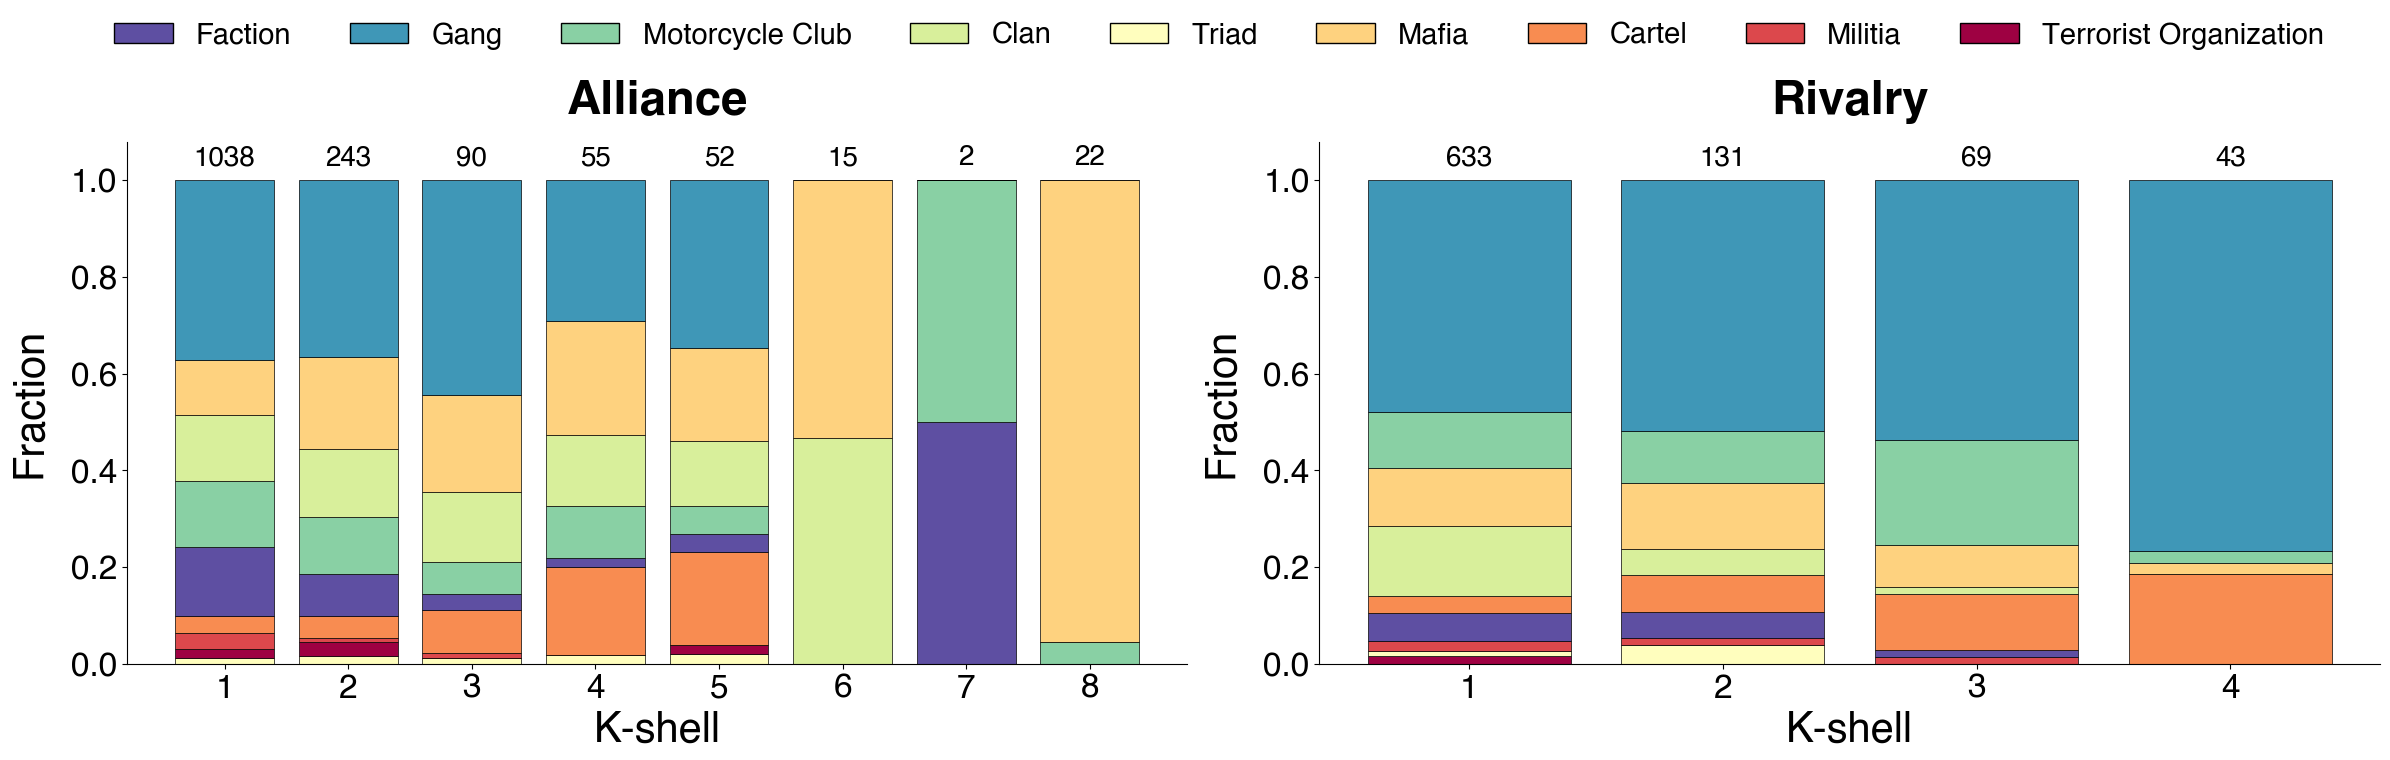

In [13]:
# Stacked bar: type composition per shell (side by side)
fig, axes = plt.subplots(1, 2, figsize=(24, 7))
style_axes(axes)
 
for ax, df_kc, layer_name in [(axes[0], df_kcore_ally, "Alliance"),
                               (axes[1], df_kcore_rival, "Rivalry")]:
    shells = sorted(df_kc["k_shell"].unique())
    type_order = df_kc["type"].value_counts().index.tolist()
    bottom = np.zeros(len(shells))
 
    for t in reversed(type_order):
        vals = [(df_kc[df_kc["k_shell"] == k]["type"] == t).sum() /
                len(df_kc[df_kc["k_shell"] == k]) for k in shells]
        ax.bar(shells, vals, bottom=bottom, color=TYPE_COLORS.get(t, "#999"),
               edgecolor="black", linewidth=0.5, width=0.8)
        bottom += vals
 
    for k in shells:
        n = len(df_kc[df_kc["k_shell"] == k])
        ax.text(k, 1.02, n, ha="center", va="bottom", fontsize=20) 
    ax.set_xlabel("K-shell", fontsize=30)
    ax.set_ylabel("Fraction", fontsize=30, labelpad = 15)
    ax.set_title(f"{layer_name}", fontsize=34, fontweight="bold", pad = 20)
    ax.set_xticks(shells)
    ax.tick_params(labelsize=24)
    ax.set_ylim(0, 1.08)
    
# Single legend at the top
handles = [
    Patch(facecolor=TYPE_COLORS.get(t, "#999"), edgecolor="black", linewidth=1,
          label=t.replace("_", " ").title())
    for t in DANGER_ORDER
]

fig.legend(handles=handles, loc="upper center", ncols=len(DANGER_ORDER),
           fontsize=21, frameon=False, bbox_to_anchor=(0.51, 1.1))
 
plt.tight_layout()
savefig("crimenet_kcore_composition")
plt.show()

# Betweenness vs pagerank

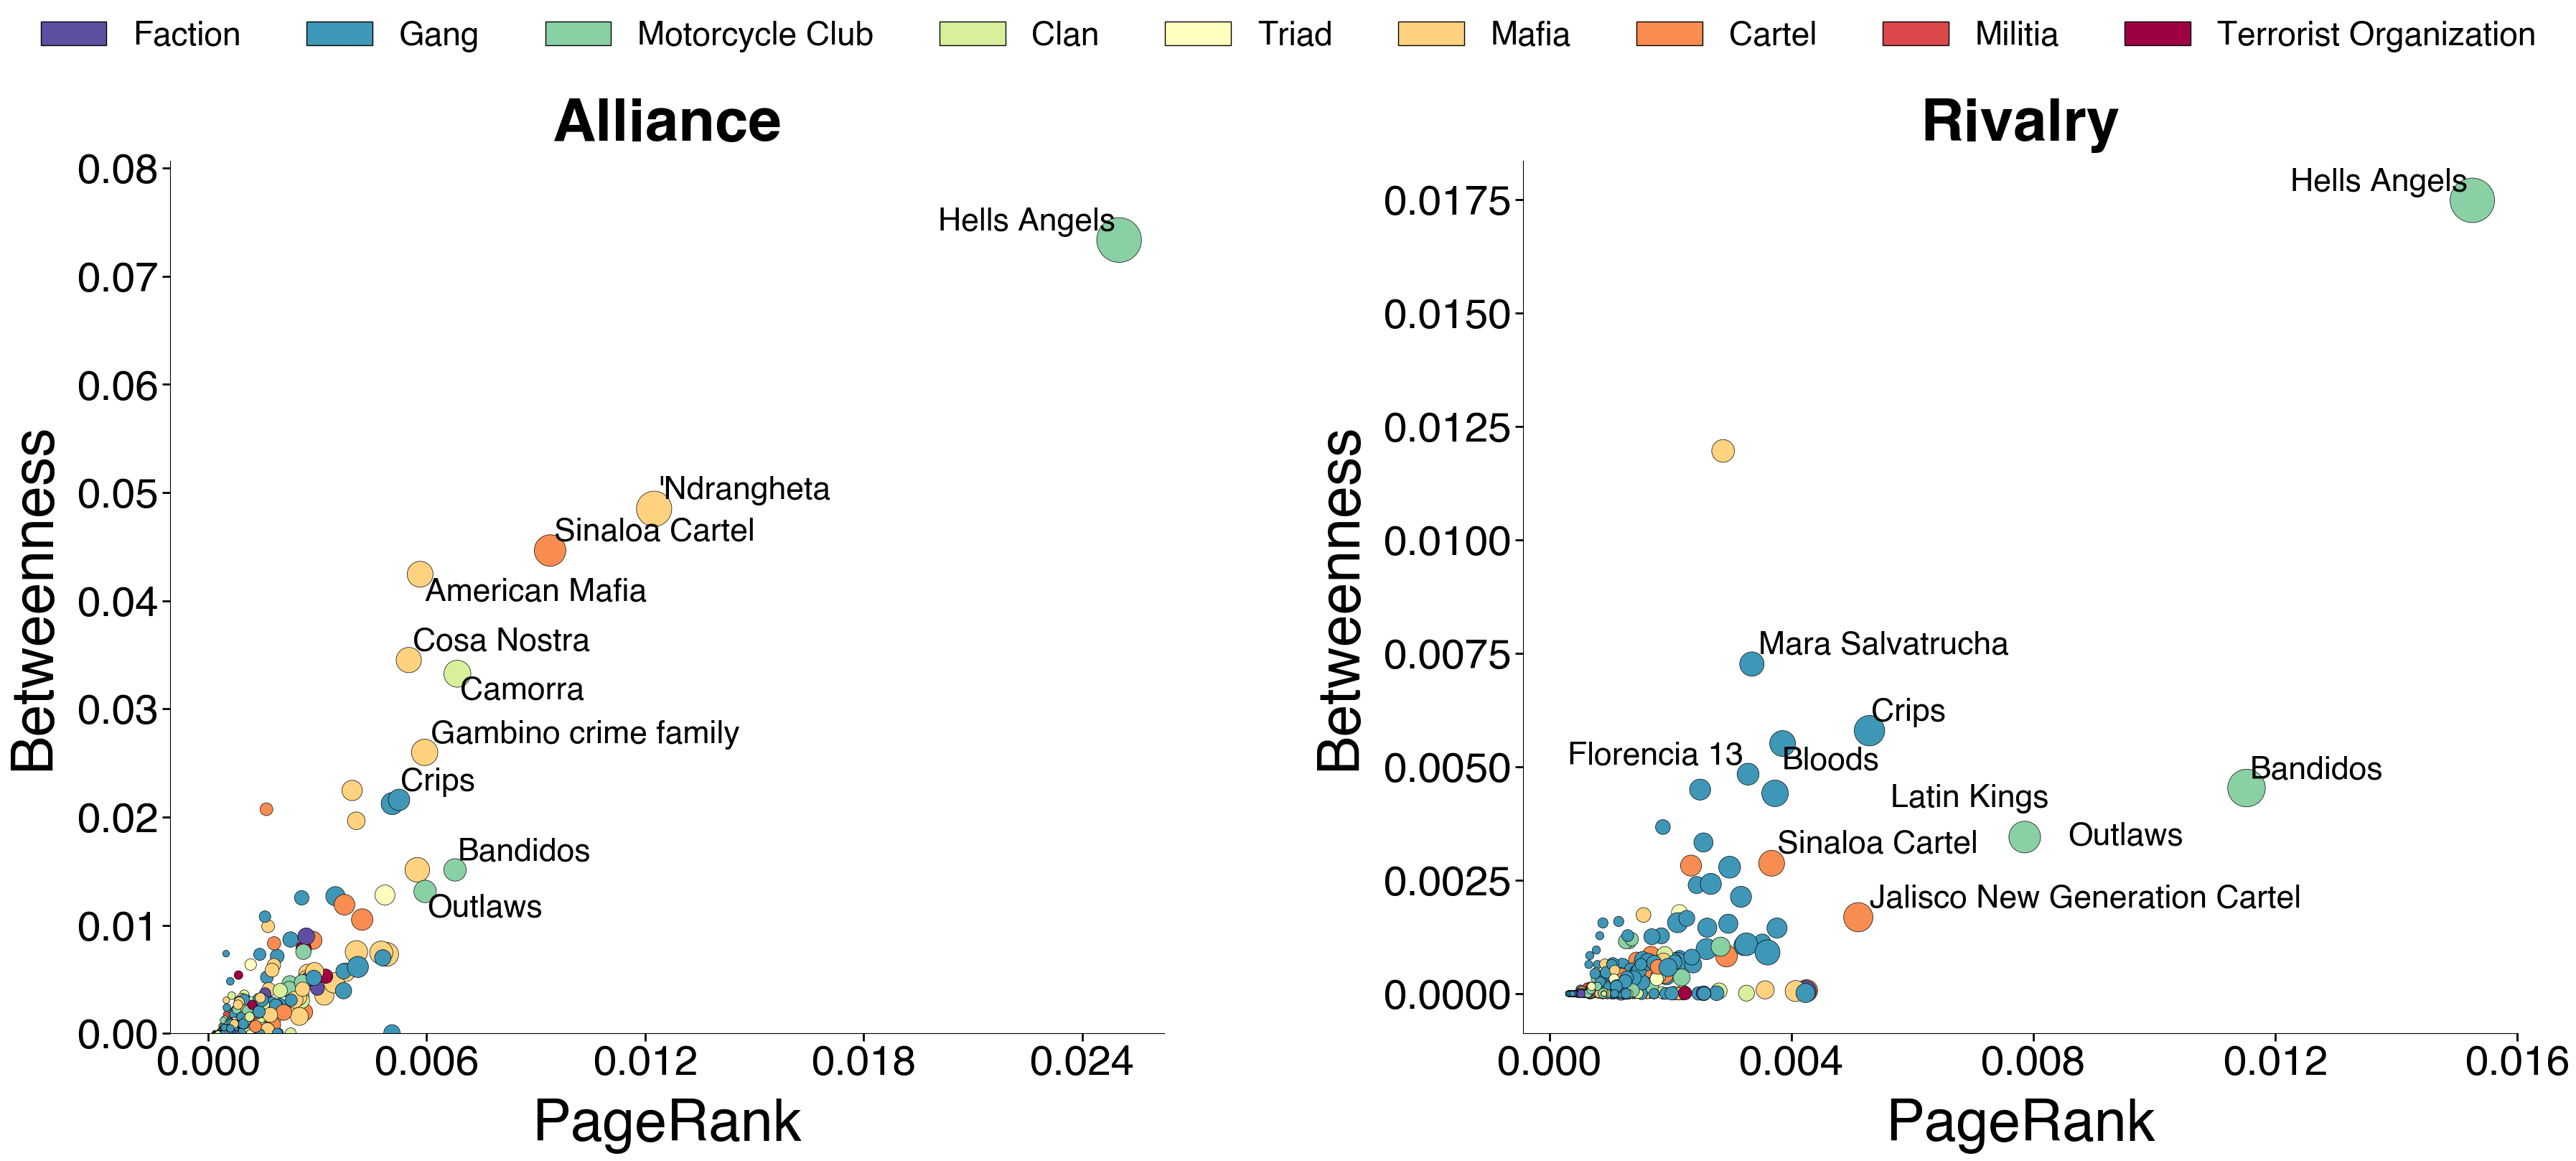

In [14]:
fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(36, 15))
style_axes(axes)

# --- Top row: PR × BC ---
for ax, edge_label, title in [(axes[0], "allied_with", "Alliance"),
                               (axes[1], "rivals_with", "Rivalry")]:
    mask = g.new_edge_property("bool")
    for e in g.edges():
        mask[e] = (ep_type[e] == edge_label)
    g_sub = GraphView(g, efilt=mask)
    pr = pagerank(g_sub)
    bw, _ = betweenness(g_sub)

    names, types, pr_v, bw_v, degs = [], [], [], [], []
    for v in g_sub.vertices():
        if v.out_degree() == 0: continue
        names.append(vp_name[v]); types.append(vp_type[v])
        pr_v.append(pr[v]); bw_v.append(bw[v]); degs.append(v.out_degree())

    pr_v, bw_v, degs = np.array(pr_v), np.array(bw_v), np.array(degs)
    colors = [TYPE_COLORS.get(t, "#999") for t in types]
    sizes = 30 + 2000 * (degs - degs.min()) / (degs.max() - degs.min() + 1)

    ax.scatter(pr_v, bw_v, c=colors, s=sizes, alpha=1,
               edgecolors="black", linewidths=0.5, zorder=3)

    rank_pr = np.argsort(-pr_v)
    rank_bw = np.argsort(-bw_v)
    combined = np.zeros(len(names))
    combined[rank_pr] += np.arange(len(names))
    combined[rank_bw] += np.arange(len(names))
    top_idx = np.argsort(combined)[:10]

    texts = [ax.text(pr_v[i], bw_v[i], names[i], fontsize=32, zorder=5)
             for i in top_idx]
    adjust_text(texts, ax=ax)
    ax.set_xlabel("PageRank", fontsize=58, labelpad=15)
    ax.set_ylabel("Betweenness", fontsize=58, labelpad=15)
    ax.set_title(title, fontsize=60, fontweight="bold", pad=20)
    ax.tick_params(labelsize=42, length=8, width=2)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    if title == 'Alliance':
        ax.set_ylim(0, bw_v.max() * 1.1)
    else:
        pass


# Single legend at the top
handles = [
    Patch(facecolor=TYPE_COLORS.get(t, "#999"), edgecolor="black", linewidth=1,
          label=t.replace("_", " ").title())
    for t in DANGER_ORDER
]

fig.legend(handles=handles, loc="upper center", ncols=len(DANGER_ORDER),
           fontsize=33, frameon=False, bbox_to_anchor=(0.5, 1.09))

plt.tight_layout(w_pad=15)
savefig("crimenet_scatter_combined")
plt.show()

# Network visualization

In [15]:
NODE_SIZE_BASE = 5
BETWEENNESS_SCALE = 100

for relation in ["allies", "rivals", "both"]:
    g_viz = Graph(directed=False)
    v_name_viz   = g_viz.new_vertex_property("string")
    v_color_edge = g_viz.new_vertex_property("string")
    v_color_type = g_viz.new_vertex_property("string")
    v_size_viz   = g_viz.new_vertex_property("double")
    e_color_def  = g_viz.new_edge_property("string")
    e_color_gray = g_viz.new_edge_property("string")

    name_to_v = {}
    def get_v(name):
        if name not in name_to_v:
            v = g_viz.add_vertex()
            v_name_viz[v]   = name
            v_color_edge[v] = "#606060"
            v_color_type[v] = TYPE_COLORS.get(entity_type_map.get(name, ""), "#606060")
            name_to_v[name] = v
        return name_to_v[name]

    for ent in entities:
        get_v(ent["name"])

    for rel in relations:
        src, tgt, rtype = rel["source"], rel["target"], rel.get("type")
        if src == tgt: continue
        if relation == "allies" and rtype != "allied_with": continue
        if relation == "rivals" and rtype != "rivals_with": continue
        if relation == "both" and rtype not in ("allied_with", "rivals_with"): continue

        e = g_viz.add_edge(get_v(src), get_v(tgt))
        e_color_def[e]  = "#3182bd" if rtype == "allied_with" else "#de2d26" if rtype == "rivals_with" else "#bdbdbd"
        e_color_gray[e] = "#bdbdbd"

    v_active = g_viz.new_vertex_property("bool")
    for v in g_viz.vertices():
        v_active[v] = v.out_degree() > 0
    g_full_viz = GraphView(g_viz, vfilt=v_active)
    lcc_filt = label_largest_component(g_full_viz)
    g_lcc_viz = GraphView(g_full_viz, vfilt=lcc_filt)

    for scope, g_view in [("full", g_full_viz), ("lcc", g_lcc_viz)]:
        bv, _ = betweenness(g_view)
        for v in g_view.vertices():
            v_size_viz[v] = NODE_SIZE_BASE + bv[v] * BETWEENNESS_SCALE

        print(f"\n{relation} ({scope}): {g_view.num_vertices()} nodes, {g_view.num_edges()} edges")
        pos = sfdp_layout(g_view, max_iter=500)

        out1 = f"images/crimenet_{relation}_{scope}.pdf"
        graph_draw(g_view, pos=pos, vertex_fill_color=v_color_edge, vertex_size=v_size_viz,
                   edge_color=e_color_def, edge_pen_width=1,
                   bg_color="white", output_size=(1600, 1600), output=out1)
        print(f"  Saved: {out1}")

        out2 = f"images/crimenet_{relation}_{scope}_types.pdf"
        graph_draw(g_view, pos=pos, vertex_fill_color=v_color_type, vertex_size=v_size_viz,
                   edge_color=e_color_gray, edge_pen_width=1,
                   bg_color="white", output_size=(1600, 1600), output=out2)
        print(f"  Saved: {out2}")



allies (full): 1517 nodes, 2293 edges
  Saved: images/crimenet_allies_full.pdf
  Saved: images/crimenet_allies_full_types.pdf

allies (lcc): 1292 nodes, 2130 edges
  Saved: images/crimenet_allies_lcc.pdf
  Saved: images/crimenet_allies_lcc_types.pdf

rivals (full): 876 nodes, 1061 edges
  Saved: images/crimenet_rivals_full.pdf
  Saved: images/crimenet_rivals_full_types.pdf

rivals (lcc): 478 nodes, 744 edges
  Saved: images/crimenet_rivals_lcc.pdf
  Saved: images/crimenet_rivals_lcc_types.pdf

both (full): 1890 nodes, 3354 edges
  Saved: images/crimenet_both_full.pdf
  Saved: images/crimenet_both_full_types.pdf

both (lcc): 1649 nodes, 3170 edges
  Saved: images/crimenet_both_lcc.pdf
  Saved: images/crimenet_both_lcc_types.pdf


# Structural importance by type

In [16]:
def compute_importance(g_layer, bw_layer, pr_layer, layer_name):
    """Compute type-level stats and print. Returns the aggregated dataframe."""
    df_t = pd.DataFrame([{
        "name": vp_name[v], "type": vp_type[v],
        "degree": v.out_degree(),
        "betweenness": bw_layer[v],
        "pagerank": pr_layer[v],
    } for v in g_layer.vertices() if v.out_degree() > 0])

    ts = df_t.groupby("type").agg(
        n=("name", "count"),
        mean_degree=("degree", "mean"), std_degree=("degree", "std"),
        mean_bw=("betweenness", "mean"), std_bw=("betweenness", "std"),
        mean_pr=("pagerank", "mean"), std_pr=("pagerank", "std"),
        total_bw=("betweenness", "sum"),
        total_pr=("pagerank", "sum"),
    ).reset_index()
    ts = ts.sort_values("mean_bw", ascending=False)

    return ts


ts_ally  = compute_importance(g_ally, bw_ally, pr_ally, "Alliance")
ts_rival = compute_importance(g_rival, bw_rival, pr_rival, "Rivalry")

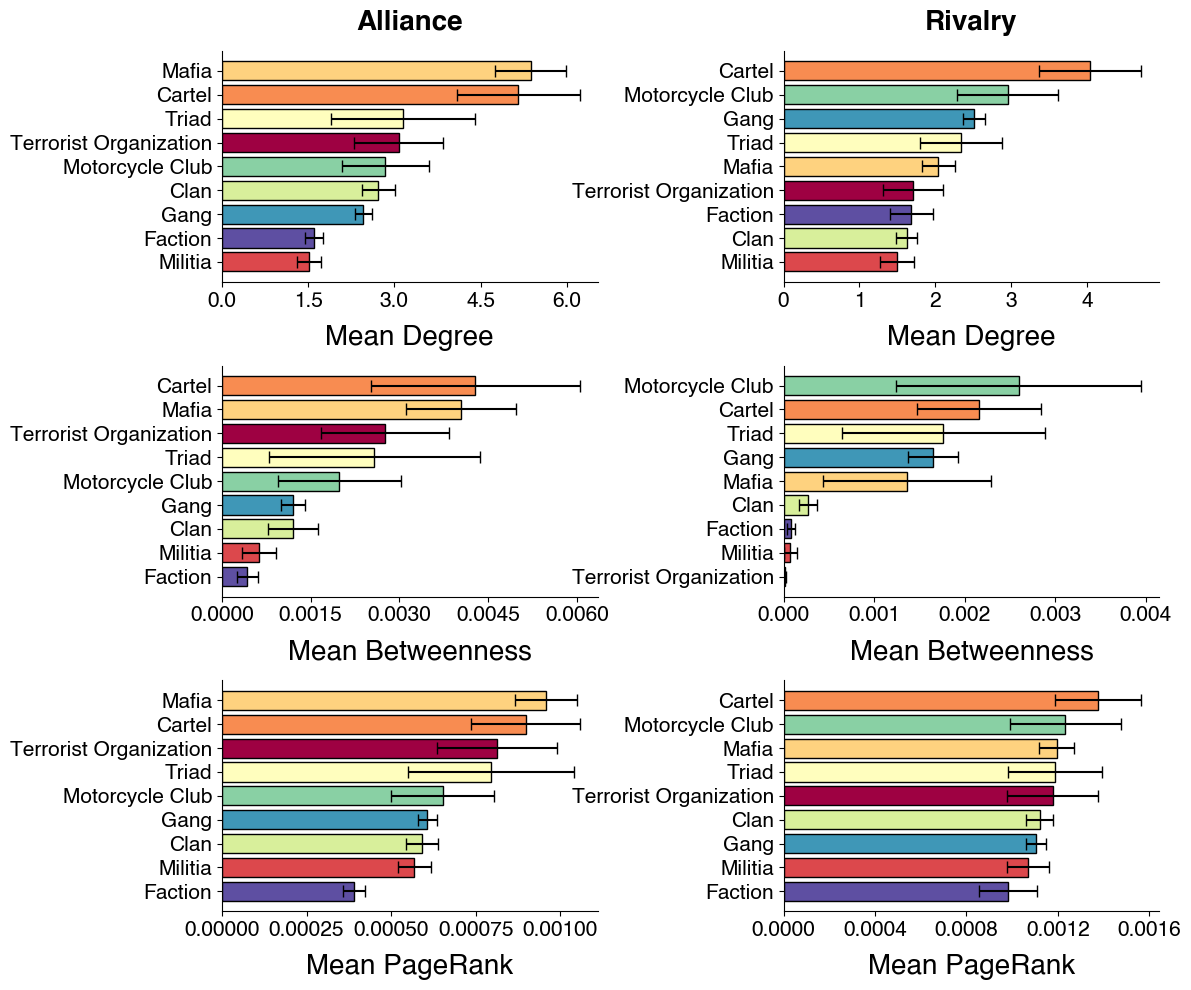

In [17]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
style_axes(axes)

plot_configs = [
    ("mean_degree", "std_degree", "Mean Degree", "Connectivity"),
    ("mean_bw", "std_bw", "Mean Betweenness", "Brokerage Power"),
    ("mean_pr", "std_pr", "Mean PageRank", "Prestige"),
]

for col, (ts, layer_name) in enumerate([(ts_ally, "Alliance"), (ts_rival, "Rivalry")]):
    for row, (mean_col, std_col, xlabel, subtitle) in enumerate(plot_configs):
        ax = axes[row, col]
        tss = ts.sort_values(mean_col)
        colors = [TYPE_COLORS.get(t, "#999") for t in tss["type"]]
        ax.barh(range(len(tss)), tss[mean_col], xerr=tss[std_col] / np.sqrt(tss["n"]),
                color=colors, capsize=4, edgecolor = 'k')
        ax.set_yticks(range(len(tss)))
        ax.set_yticklabels([t.replace("_", " ").title() for t in tss["type"]], fontsize=20)
        ax.set_xlabel(xlabel, fontsize=20, labelpad=10)
        ax.tick_params(labelsize=15)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))

        # Title: layer name on top row, metric name always
        if row == 0:
            ax.set_title(f"{layer_name}", fontsize=20, fontweight="bold", pad=15)
        else:
            pass
            #ax.set_title(subtitle, fontsize=18, fontweight="bold", pad=10)

plt.tight_layout(w_pad=-2.5)
savefig("crimenet_importance_by_type")
plt.show()

# Signed network analysis

In [18]:
# Build signed edge sets (contradictory edges stay in both)
ally_edges  = set()
rival_edges = set()
for rel in relations:
    src, tgt = rel["source"], rel["target"]
    if src == tgt: continue
    edge = tuple(sorted([src, tgt]))
    if rel["type"] == "allied_with":  ally_edges.add(edge)
    elif rel["type"] == "rivals_with": rival_edges.add(edge)
 
contradictory = ally_edges & rival_edges
print(f"Signed network: {len(ally_edges)} alliances, {len(rival_edges)} rivalries, "
      f"{len(contradictory)} contradictory")
 
ally_nb  = defaultdict(set)
rival_nb = defaultdict(set)
for a, b in ally_edges:  ally_nb[a].add(b);  ally_nb[b].add(a)
for a, b in rival_edges: rival_nb[a].add(b); rival_nb[b].add(a)
all_signed_nodes = sorted(set(ally_nb) | set(rival_nb))
 
df_signed = pd.DataFrame([{
    "name": n, "type": entity_type_map.get(n, "unknown"),
    "d_pos": len(ally_nb.get(n, set())),
    "d_neg": len(rival_nb.get(n, set())),
    "d_total": len(ally_nb.get(n, set())) + len(rival_nb.get(n, set())),
} for n in all_signed_nodes])
df_signed["signed_deg"]  = df_signed["d_pos"] - df_signed["d_neg"]
df_signed["controversy"] = df_signed["d_pos"] * df_signed["d_neg"]
 
# %%
print("Top 15 most CONTROVERSIAL (many allies AND rivals):")
for _, r in df_signed.nlargest(15, "controversy").iterrows():
    print(f"  {r['name']:45s}  +{r['d_pos']:3d} / -{r['d_neg']:3d}  type={r['type']}")
 
print("\nTop 10 PURE COOPERATORS (5+ allies, 0 rivals):")
coop = df_signed[(df_signed["d_neg"] == 0) & (df_signed["d_pos"] >= 5)]
for _, r in coop.nlargest(10, "d_pos").iterrows():
    print(f"  {r['name']:45s}  +{r['d_pos']:3d} / -{r['d_neg']:3d}  type={r['type']}")
    
print("\nTop 10 PURE ANTAGONISTS (5+ rivals, 0 allies):")
antag = df_signed[(df_signed["d_pos"] == 0) & (df_signed["d_neg"] >= 5)]
for _, r in antag.nlargest(10, "d_neg").iterrows():
    print(f"  {r['name']:45s}  +{r['d_pos']:3d} / -{r['d_neg']:3d}  type={r['type']}")

if contradictory:
    print(f"\n{len(contradictory)} contradictory edges (both ally + rival):")
    for a, b in sorted(contradictory)[:20]:
        print(f"  {a:35s} <-> {b}")

Signed network: 2293 alliances, 1061 rivalries, 0 contradictory
Top 15 most CONTROVERSIAL (many allies AND rivals):
  Hells Angels                                   +134 / - 53  type=motorcycle_club
  Bandidos                                       + 33 / - 38  type=motorcycle_club
  Sinaloa Cartel                                 + 66 / - 18  type=cartel
  Outlaws                                        + 33 / - 27  type=motorcycle_club
  Crips                                          + 30 / - 25  type=gang
  Bloods                                         + 32 / - 18  type=gang
  Mexican Mafia                                  + 40 / - 14  type=mafia
  Jalisco New Generation Cartel                  + 21 / - 23  type=cartel
  Latin Kings                                    + 24 / - 19  type=gang
  Gulf Cartel                                    + 30 / - 13  type=cartel
  Los Zetas                                      + 28 / - 12  type=cartel
  Yamaguchi-gumi                                 +

# Role persistence across layers

In [19]:
# Compute ranks — filtering to centrality > 0
m_a_dict = {vp_name[v]: {"bw": bw_ally[v], "pr": pr_ally[v], "deg": v.out_degree(), "type": vp_type[v]}
            for v in g_ally.vertices() if v.out_degree() > 0}
m_r_dict = {vp_name[v]: {"bw": bw_rival[v], "pr": pr_rival[v], "deg": v.out_degree(), "type": vp_type[v]}
            for v in g_rival.vertices() if v.out_degree() > 0}

common_all = sorted(set(m_a_dict) & set(m_r_dict))
print(f"Orgs active in both layers: {len(common_all)}")

# For each metric, keep only orgs with value > 0 in at least one layer
common_by_metric = {
    "deg": [n for n in common_all if m_a_dict[n]["deg"] > 0 or m_r_dict[n]["deg"] > 0],
    "bw":  [n for n in common_all if m_a_dict[n]["bw"] > 0 or m_r_dict[n]["bw"] > 0],
    "pr":  [n for n in common_all if m_a_dict[n]["pr"] > 0 or m_r_dict[n]["pr"] > 0],
}
for m, lst in common_by_metric.items():
    print(f"  {m}: {len(lst)} orgs with value > 0 in at least one layer")

# Build separate rank dataframes per metric
df_ranks = {}
for metric_key, metric_label in [("deg", "Degree"), ("bw", "Betweenness"), ("pr", "PageRank")]:
    common = common_by_metric[metric_key]
    N = len(common)
    order_a = sorted(common, key=lambda n: -m_a_dict[n][metric_key])
    order_r = sorted(common, key=lambda n: -m_r_dict[n][metric_key])
    rank_a = {n: i + 1 for i, n in enumerate(order_a)}
    rank_r = {n: i + 1 for i, n in enumerate(order_r)}

    df = pd.DataFrame([{
        "name": n, "type": m_a_dict[n]["type"],
        "deg_max": max(m_a_dict[n]["deg"], m_r_dict[n]["deg"]),
        "rank_a": rank_a[n], "rank_r": rank_r[n],
        "delta": rank_a[n] - rank_r[n],
    } for n in common])
    df_ranks[metric_key] = (df, N, metric_label)

# %%
# Print role persistence for all three metrics
for metric_key in ["deg", "bw", "pr"]:
    df, N, label = df_ranks[metric_key]
    print(f"\n{'='*60}")
    print(f"{label} — Role Persistence (n={N}, filtered to value > 0)")
    print(f"{'='*60}")

    print(f"\nTop 10 BETTER in ALLIANCE than RIVALRY ({label}):")
    for _, r in df.nsmallest(10, "delta").iterrows():
        print(f"  {r['name']:40s}  type={r['type']:22s}  ally_rank={int(r['rank_a']):4d}  rival_rank={int(r['rank_r']):4d}  Δ={int(r['delta']):+5d}")

    print(f"\nTop 10 BETTER in RIVALRY than ALLIANCE ({label}):")
    for _, r in df.nlargest(10, "delta").iterrows():
        print(f"  {r['name']:40s}  type={r['type']:22s}  ally_rank={int(r['rank_a']):4d}  rival_rank={int(r['rank_r']):4d}  Δ={int(r['delta']):+5d}")
        
# Persistent organizations: ranked highly in BOTH networks.
# Score = max(rank_a, rank_r). Lower is better (top in both).
# Tiebreak by |Δ|: among orgs with the same worst-rank, prefer smaller gap.

for metric_key in ["deg", "bw", "pr"]:
    df, N, label = df_ranks[metric_key]
    df = df.copy()
    df["worst_rank"] = df[["rank_a", "rank_r"]].max(axis=1)
    df["abs_delta"]  = df["delta"].abs()
    df_sorted = df.sort_values(["worst_rank", "abs_delta"]).head(15)

    print(f"\n{'='*70}")
    print(f"{label} — Most PERSISTENT (top in both networks, n={N})")
    print(f"{'='*70}")
    for _, r in df_sorted.iterrows():
        print(f"  {r['name']:40s}  type={r['type']:22s}  "
              f"ally={int(r['rank_a']):4d}  rival={int(r['rank_r']):4d}  "
              f"|Δ|={int(r['abs_delta']):4d}")
    

Orgs active in both layers: 503
  deg: 503 orgs with value > 0 in at least one layer
  bw: 376 orgs with value > 0 in at least one layer
  pr: 503 orgs with value > 0 in at least one layer

Degree — Role Persistence (n=503, filtered to value > 0)

Top 10 BETTER in ALLIANCE than RIVALRY (Degree):
  Serbian mafia                             type=mafia                   ally_rank=  26  rival_rank= 469  Δ= -443
  Secondigliano Alliance                    type=clan                    ally_rank=  52  rival_rank= 468  Δ= -416
  The British                               type=gang                    ally_rank=  80  rival_rank= 486  Δ= -406
  Pittsburgh crime family                   type=mafia                   ally_rank=  47  rival_rank= 446  Δ= -399
  Lucchese crime family                     type=mafia                   ally_rank=  19  rival_rank= 405  Δ= -386
  Rinaldi clan                              type=clan                    ally_rank=  79  rival_rank= 457  Δ= -378
  Nazi Lowriders   

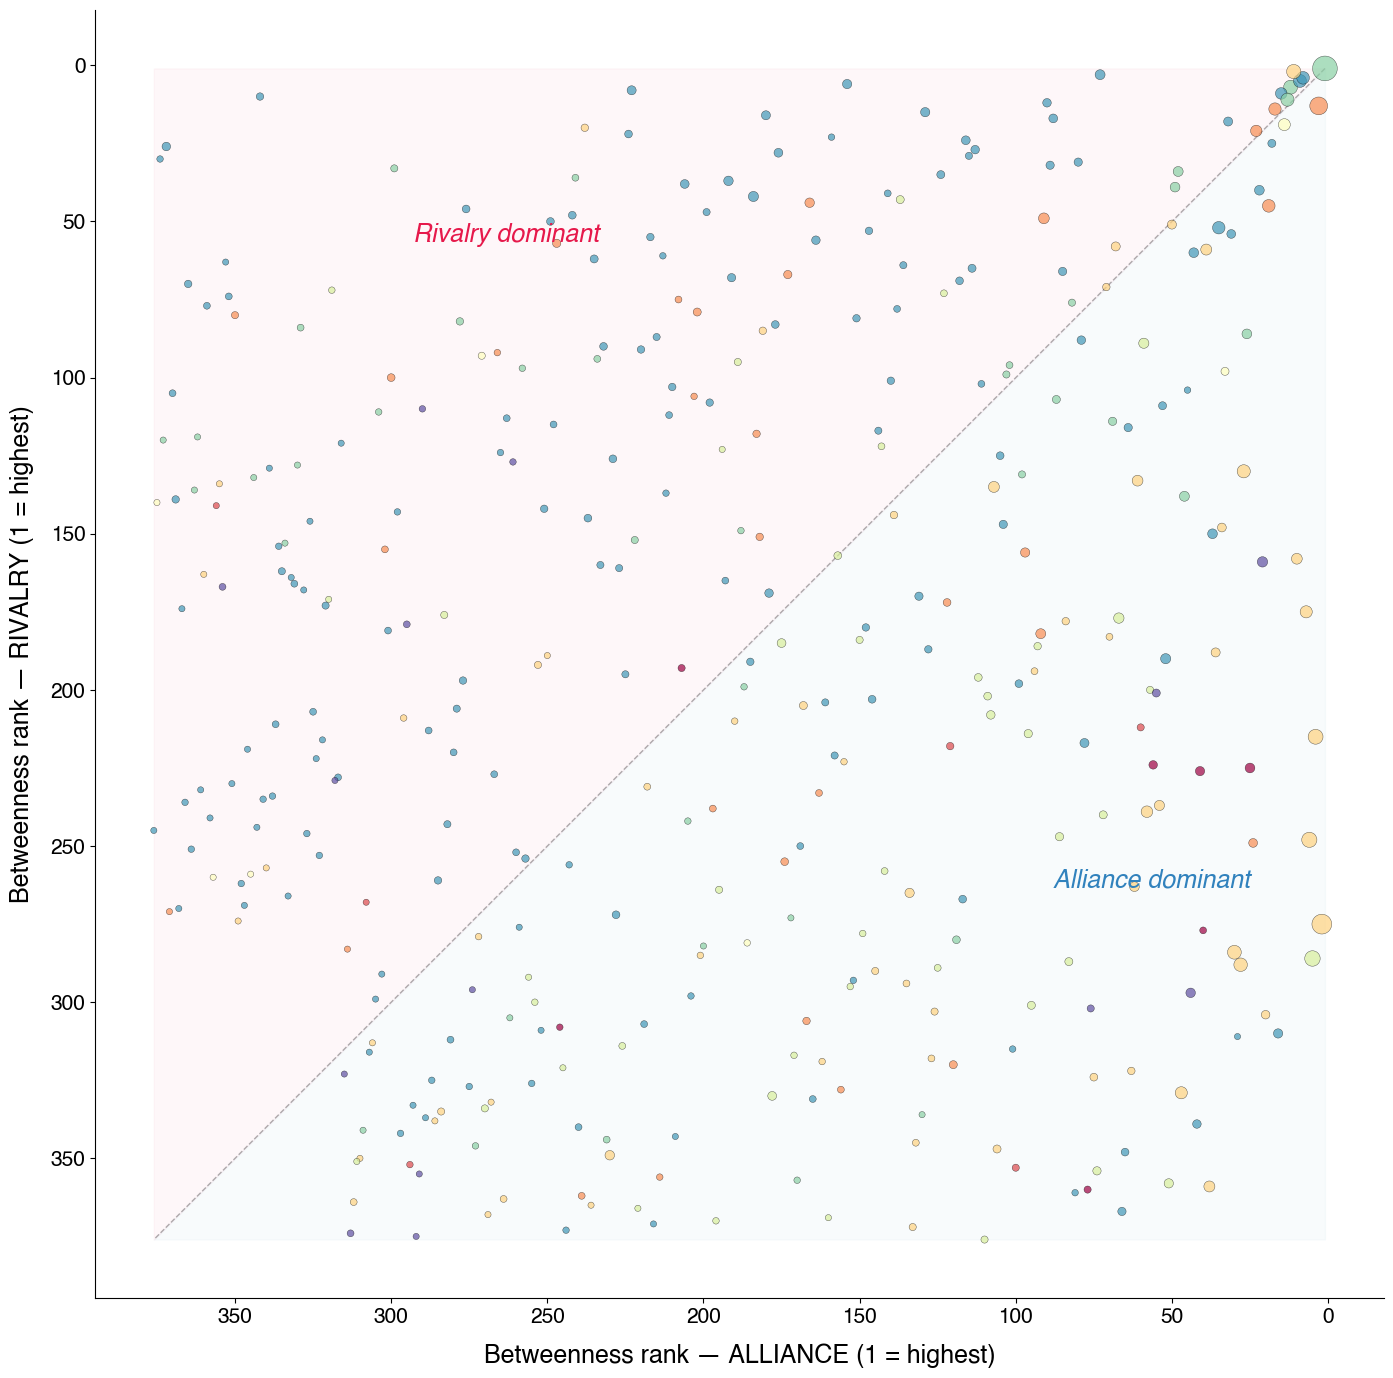

In [20]:
# Plot: betweenness only (filtered to bw > 0)
df_bw, N_bw, _ = df_ranks["bw"]

fig, ax = plt.subplots(figsize=(14, 14))
style_ax(ax)
colors = [TYPE_COLORS.get(r["type"], "#999") for _, r in df_bw.iterrows()]
d = df_bw["deg_max"].values
sizes = 20 + 300 * (d - d.min()) / (d.max() - d.min() + 1)

ax.scatter(df_bw["rank_a"], df_bw["rank_r"], c=colors, s=sizes,
           alpha=0.7, edgecolors="black", linewidths=0.3, zorder=3)
ax.plot([1, N_bw], [1, N_bw], "--", color="black", alpha=0.3, lw=1)

ax.fill_between([1, N_bw], [1, N_bw], [N_bw, N_bw], alpha=0.03, color="#3182bd")
ax.fill_between([1, N_bw], [1, 1], [1, N_bw], alpha=0.03, color="#e6194b")
ax.text(N_bw*0.7, N_bw*0.15, "Rivalry dominant", fontsize=18, color="#e6194b", alpha=1, ha="center", style="italic")
ax.text(N_bw*0.15, N_bw*0.7, "Alliance dominant", fontsize=18, color="#3182bd", alpha=1, ha="center", style="italic")

# N_LABELS = 3
# delta = df_bw["delta"]
# to_label = (
#     df_bw.loc[delta.nsmallest(N_LABELS).index, "name"].tolist() +
#     df_bw.loc[delta.nlargest(N_LABELS).index, "name"].tolist()
# )
# texts = [ax.text(df_bw[df_bw["name"] == n]["rank_a"].values[0],
#                  df_bw[df_bw["name"] == n]["rank_r"].values[0],
#                  n, fontsize=14, ha="center") for n in to_label]
# adjust_text(texts, ax=ax, expand_points=(2.8, 2.8), force_points=0.2)

ax.set_xlabel("Betweenness rank — ALLIANCE (1 = highest)", fontsize=18, labelpad=12)
ax.set_ylabel("Betweenness rank — RIVALRY (1 = highest)", fontsize=18, labelpad=12)
ax.tick_params(labelsize=15)
ax.invert_xaxis(); ax.invert_yaxis(); ax.set_aspect("equal")
plt.tight_layout()
savefig("crimenet_role_persistence")
plt.show()

# Alliance share

Type                          n   Ally %             95% CI
------------------------------------------------------------
Mafia                       263    86.1%       [82.5, 89.1]
Terrorist Organization       28    82.5%       [71.2, 90.1]
Faction                     192    79.1%       [73.5, 85.0]
Clan                        251    77.9%       [73.6, 82.1]
Militia                      46    71.1%       [62.4, 80.3]
Triad                        23    69.2%       [54.7, 77.5]
Cartel                       88    66.2%       [59.6, 72.0]
Motorcycle Club             233    63.6%       [57.7, 68.3]
Gang                        766    54.8%       [52.1, 57.5]


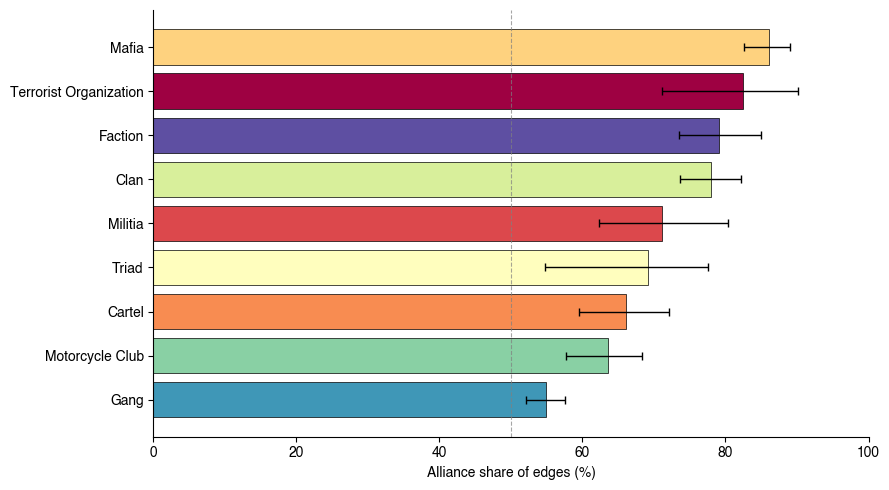

In [21]:
# ─── 1. Build per-org table ────────────────────────────────────────
rows = []
for n in all_signed_nodes:
    d_pos = len(ally_nb.get(n, set()))
    d_neg = len(rival_nb.get(n, set()))
    if d_pos + d_neg == 0: continue
    rows.append({
        "name": n,
        "type": entity_type_map.get(n, "unknown"),
        "d_pos": d_pos,
        "d_neg": d_neg,
    })
df_prop = pd.DataFrame(rows)

# ─── 2. Edge-weighted point estimates per type ─────────────────────
type_prop = df_prop.groupby("type").agg(
    n=("name", "count"),
    total_ally=("d_pos", "sum"),
    total_rival=("d_neg", "sum"),
).reset_index()
type_prop["total_edges"] = type_prop["total_ally"] + type_prop["total_rival"]
type_prop["ew_ally_frac"] = type_prop["total_ally"] / type_prop["total_edges"]

# ─── 3. Bootstrap 95% CI over organizations ────────────────────────
rng = default_rng(42)
B = 2000

ci_rows = []
for t, grp in df_prop.groupby("type"):
    if len(grp) < 10:
        continue
    pos = grp["d_pos"].values
    neg = grp["d_neg"].values
    n = len(grp)
    fracs = np.empty(B)
    for b in range(B):
        idx = rng.integers(0, n, size=n)
        a = pos[idx].sum()
        r = neg[idx].sum()
        fracs[b] = a / (a + r) if (a + r) > 0 else np.nan
    lo, hi = np.nanpercentile(fracs, [2.5, 97.5])
    ci_rows.append({"type": t, "ci_lo": lo, "ci_hi": hi})

ci_df = pd.DataFrame(ci_rows)
type_prop = type_prop.merge(ci_df, on="type", how="inner")
type_prop = type_prop.sort_values("ew_ally_frac", ascending=True).reset_index(drop=True)

# ─── 4. Print table ────────────────────────────────────────────────
label_map = {
    "gang": "Gang", "motorcycle_club": "Motorcycle Club", "triad": "Triad",
    "terrorist_organization": "Terrorist Organization", "faction": "Faction",
    "cartel": "Cartel", "militia": "Militia", "clan": "Clan", "mafia": "Mafia",
}
type_prop["label"] = type_prop["type"].map(label_map).fillna(type_prop["type"])

print(f"{'Type':25s} {'n':>5s} {'Ally %':>8s} {'95% CI':>18s}")
print("-" * 60)
for _, r in type_prop.iloc[::-1].iterrows():
    ci_str = f"[{r['ci_lo']*100:.1f}, {r['ci_hi']*100:.1f}]"
    print(f"{r['label']:25s} {int(r['n']):5d} {r['ew_ally_frac']*100:7.1f}% {ci_str:>18s}")

# ─── 5. Plot: alliance % by type, colored by TYPE_COLORS ──────────
fig, ax = plt.subplots(figsize=(9, 5))

y = np.arange(len(type_prop))
vals   = type_prop["ew_ally_frac"].values * 100
err_lo = (type_prop["ew_ally_frac"].values - type_prop["ci_lo"].values) * 100
err_hi = (type_prop["ci_hi"].values - type_prop["ew_ally_frac"].values) * 100
colors = [TYPE_COLORS.get(t, "#999") for t in type_prop["type"]]

ax.barh(
    y, vals,
    color=colors,
    edgecolor="black", linewidth=0.5,
    xerr=[err_lo, err_hi],
    error_kw={"ecolor": "black", "elinewidth": 1.0, "capsize": 3},
)

ax.axvline(50, color="gray", linewidth=0.8, linestyle="--", alpha=0.7)

ax.set_yticks(y)
ax.set_yticklabels(type_prop["label"])
ax.set_xlabel("Alliance share of edges (%)")
ax.set_xlim(0, 100)
ax.set_xticks(np.arange(0, 101, 20))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("images/crimenet_alliance_share_by_type.pdf", bbox_inches="tight")
plt.show()